
# Cardiovascular Disease Risk Prediction using Machine Learning


## Student A - Binary Classification

### Problem Statement
Problem statement: Build a web application that accepts a patient’s clinical measurements
(age, blood pressure, cholesterol, BMI, smoking status) and outputs a personalised cardiovascular
disease risk score with an explanation of the top contributing factors. The application targets
primary healthcare workers in rural clinics who lack specialist access.


Dataset: 70,000 patient records, 11 features, binary target (disease / no disease). Cardiovascular


### Algorithms
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost




# Goal
Goal---> A Predict CVD risk(binary classification) with Logistic
Regression, Random Forest, XGBoost.
Tune decision threshold for high recall(i.e. reduce FN)

Technique ---> Supervised classification,GridSearchCV,AUC-ROC

WEB Application part ---> Risk prediction API endpoint

In [80]:
# IMPORT REQUIRED LIBRARIES

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


from sklearn.metrics import ( recall_score, f1_score,roc_auc_score,roc_curve,
    accuracy_score,precision_score,
   
 confusion_matrix,classification_report,precision_recall_curve
)

# trhis lib is for saving best model  in .pkl format
import joblib

# os consumption calculation
import os
import time
import psutil
import tracemalloc


import warnings
warnings.filterwarnings("ignore")


plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv

# Load Dataset

In [81]:
# Load Datset

# Dataset Path
DATASET_PATH = "/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv"
# Inject Dataset
df = pd.read_csv(DATASET_PATH, sep=";")


print("DataSet Loaded")
print(f"Dataset Shape : {df.shape}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst Five Rows:")
display(df.head(3))

DataSet Loaded
Dataset Shape : (70000, 13)

Column Names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

First Five Rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1


# EDA

Dataset Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

Statistical Summary


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000



Missing Values


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


Duplicate Records: 0


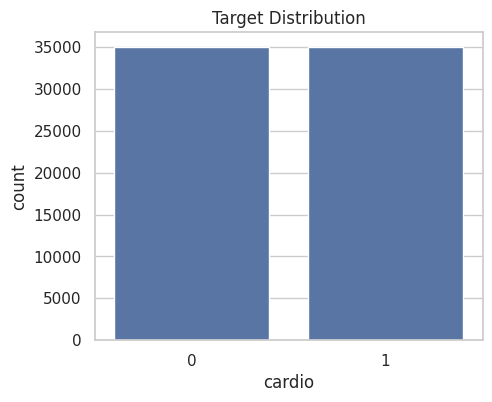

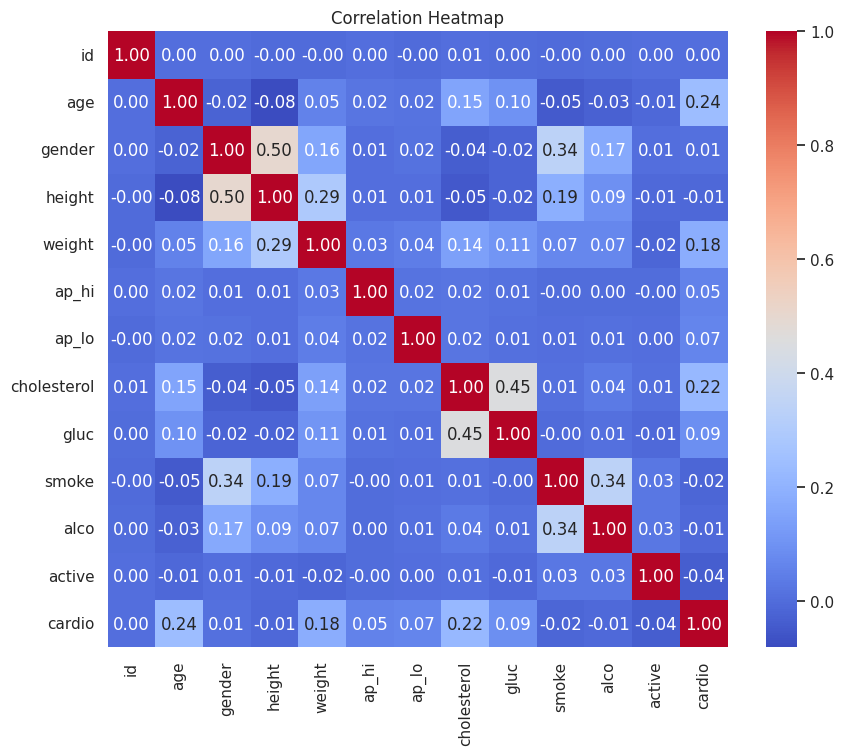

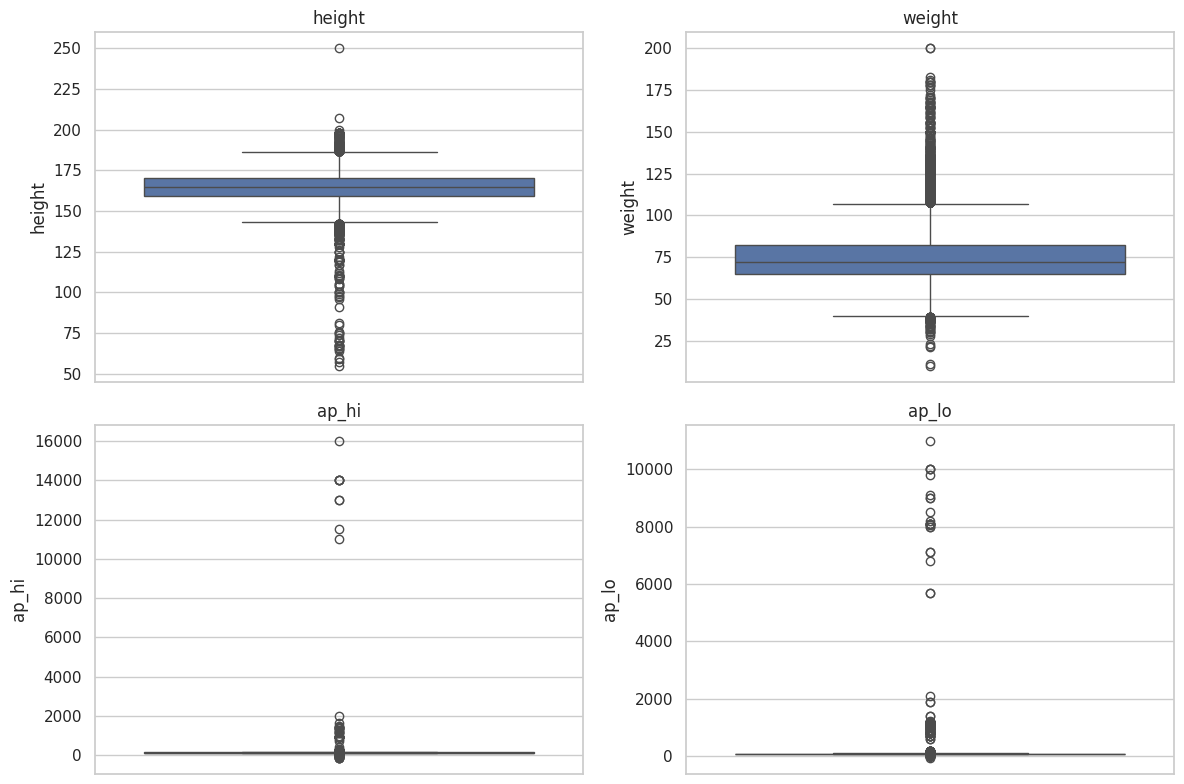

In [82]:
# =============================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

# Dataset Overview
print("Dataset Shape:", df.shape)

display(df.head())

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe())

# Missing Values
print("\nMissing Values")
display(df.isnull().sum())

# Duplicate Records
print("\nDuplicate Records:", df.duplicated().sum())

# Target Distribution
plt.figure(figsize=(5,4))
sns.countplot(x="cardio", data=df)
plt.title("Target Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Outlier Detection
cols = ["height", "weight", "ap_hi", "ap_lo"]

plt.figure(figsize=(12,8))

for i, col in enumerate(cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Feature Selection

In [83]:
# =============================================================================
# FEATURE SELECTION
# =============================================================================
df_clean = df.copy()
# Remove id
df_clean.drop(columns=["id"], inplace=True)
X = df_clean.drop("cardio", axis=1)
y = df_clean["cardio"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

display(X.head(3))
display(y.head(3))




# Train-Test Split
# =============================================================================
# TRAIN - TEST SPLIT
# =============================================================================

from sklearn.model_selection import train_test_split
# train:test   70% : 30%
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.30, random_state=42, stratify=y
)


print("TRAIN - TEST SPLIT")


print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)





Feature Matrix Shape : (70000, 11)
Target Shape : (70000,)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
0,18393,2,168,62.0,110,80,1,1,0,0,1
1,20228,1,156,85.0,140,90,3,1,0,0,1
2,18857,1,165,64.0,130,70,3,1,0,0,0


0    0
1    1
2    1
Name: cardio, dtype: int64

TRAIN - TEST SPLIT
Training Features : (49000, 11)
Testing Features  : (21000, 11)
Training Labels   : (49000,)
Testing Labels    : (21000,)


#  MODEL SELECTION   (ML supervised  ALGORITHM) 

# MODEL-1  :    Logistic Regression Training

In [84]:

# FEATURE SCALING

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Logistic Regression Data  feature scalling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("FEATURE SCALING COMPLETED")


print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

FEATURE SCALING COMPLETED
Scaled Training Shape : (49000, 11)
Scaled Testing Shape  : (21000, 11)


In [85]:
# LOGISTIC REGRESSION

# object creation or  untrained model creation of   algo   of  library sklearn
lr_model = LogisticRegression(random_state=42,max_iter=1000)

start_time = time.time()
# training the model on train data   scales x_train,y_train
lr_model.fit(X_train_scaled, y_train)

lr_training_time = time.time() - start_time


print("LOGISTIC REGRESSION TRAINED")


print(f"Training Time : {lr_training_time:.4f} seconds")





# LOGISTIC REGRESSION PREDICTION


start_time = time.time()

lr_pred = lr_model.predict(X_test_scaled)

lr_prediction_time = time.time() - start_time

lr_probability = lr_model.predict_proba(X_test_scaled)[:,1]

print("="*70)
print("PREDICTION COMPLETED")
print("="*70)

print(f"Prediction Time : {lr_prediction_time:.4f} seconds")






# LOGISTIC REGRESSION EVALUATION

print("LOGISTIC REGRESSION PERFORMANCE")


accuracy = accuracy_score(y_test, lr_pred)
precision = precision_score(y_test, lr_pred)
recall = recall_score(y_test, lr_pred)
f1 = f1_score(y_test, lr_pred)
auc = roc_auc_score(y_test, lr_probability)



# as per our dataset  our  model  matrix  order where  recall is priority 
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Accuracy  : {accuracy:.4f}")

print("\nClassification Report")
print(classification_report(y_test, lr_pred))











LOGISTIC REGRESSION TRAINED
Training Time : 0.2364 seconds
PREDICTION COMPLETED
Prediction Time : 0.0037 seconds
LOGISTIC REGRESSION PERFORMANCE
Recall    : 0.6720
F1 Score  : 0.6998
ROC AUC   : 0.7760
Precision : 0.7299
Accuracy  : 0.7119

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.75      0.72     10506
           1       0.73      0.67      0.70     10494

    accuracy                           0.71     21000
   macro avg       0.71      0.71      0.71     21000
weighted avg       0.71      0.71      0.71     21000



# CONFUSION MATRIX

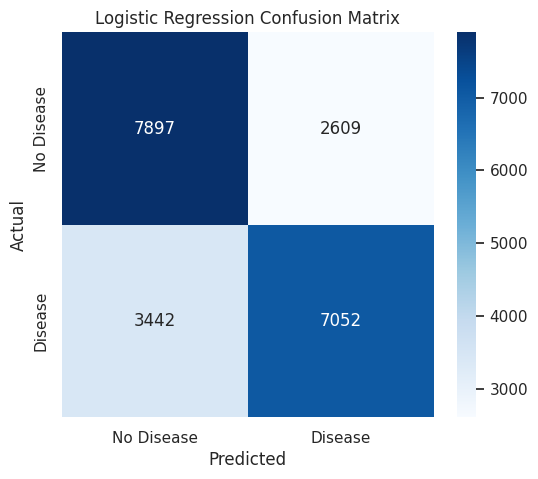

In [86]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

# Random Forest Training

RANDOM FOREST TRAINED
Training Time : 2.8189 seconds
PREDICTION COMPLETED
Prediction Time : 0.1925 seconds
RANDOM FOREST PERFORMANCE
Accuracy  : 0.7121
Precision : 0.7176
Recall    : 0.6990
F1 Score  : 0.7081
ROC AUC   : 0.7718

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.73      0.72     10506
           1       0.72      0.70      0.71     10494

    accuracy                           0.71     21000
   macro avg       0.71      0.71      0.71     21000
weighted avg       0.71      0.71      0.71     21000



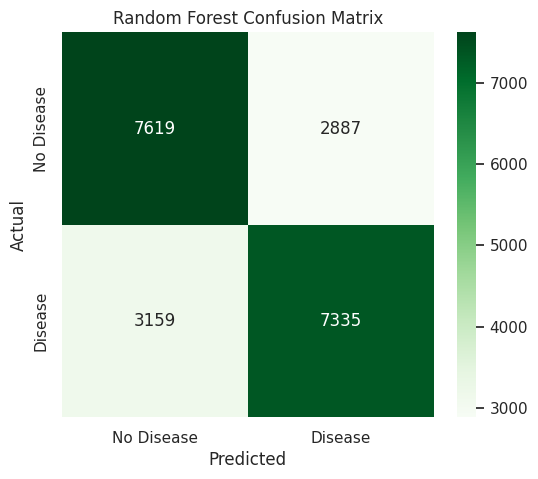

In [87]:
# RANDOM FOREST CLASSIFIER
# =============================================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Training Time
start_time = time.time()

rf_model.fit(X_train, y_train)

rf_training_time = time.time() - start_time

print("="*70)
print("RANDOM FOREST TRAINED")
print("="*70)

print(f"Training Time : {rf_training_time:.4f} seconds")









# RANDOM FOREST PREDICTION

start_time = time.time()

rf_pred = rf_model.predict(X_test)

rf_prediction_time = time.time() - start_time

rf_probability = rf_model.predict_proba(X_test)[:,1]

print("="*70)
print("PREDICTION COMPLETED")
print("="*70)

print(f"Prediction Time : {rf_prediction_time:.4f} seconds")








# RANDOM FOREST PERFORMANCE

print("="*70)
print("RANDOM FOREST PERFORMANCE")
print("="*70)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_probability)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC AUC   : {rf_auc:.4f}")

print("\nClassification Report")

print(classification_report(y_test, rf_pred))









# =============================================================================
# RANDOM FOREST CONFUSION MATRIX  ---> 
# jo jaisa tha baisa hin model ne pridict kiya 
# TP(disease the, diseas yes pridict kiya),
# TN (disease nahi the, diseas no pridict kiya)   

# jo jaisa tha thik uske bipirit model ne pridict kiya after gitting trained
# FP(disease the, diseas  no pridict kiya,
# FN(disease nahi the, diseas yes pridict kiya)
# =============================================================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()


# XGBoost

XGBOOST TRAINED
Training Time : 0.2354 seconds
PREDICTION COMPLETED
Prediction Time : 0.0214 seconds
XGBOOST PERFORMANCE
Accuracy  : 0.7339
Precision : 0.7548
Recall    : 0.6925
F1 Score  : 0.7223
ROC AUC   : 0.8000

Classification Report

              precision    recall  f1-score   support

           0       0.72      0.78      0.74     10506
           1       0.75      0.69      0.72     10494

    accuracy                           0.73     21000
   macro avg       0.74      0.73      0.73     21000
weighted avg       0.74      0.73      0.73     21000



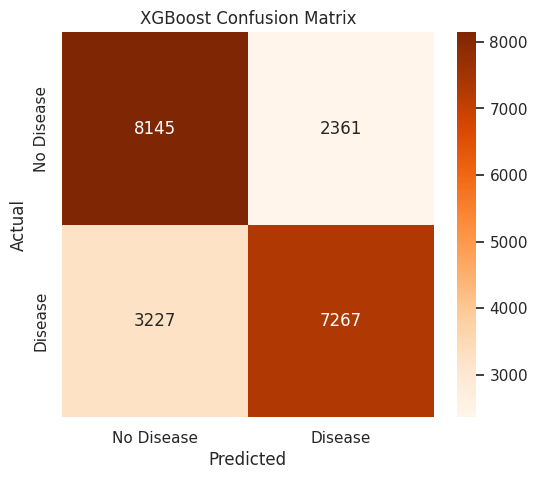

In [88]:
# =============================================================================
# XGBOOST CLASSIFIER  Training
# =============================================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

# Training Time
start_time = time.time()

xgb_model.fit(X_train, y_train)

xgb_training_time = time.time() - start_time

print("="*70)
print("XGBOOST TRAINED")
print("="*70)

print(f"Training Time : {xgb_training_time:.4f} seconds")



# =============================================================================
# XGBOOST PREDICTION
# =============================================================================

start_time = time.time()

xgb_pred = xgb_model.predict(X_test)

xgb_prediction_time = time.time() - start_time

xgb_probability = xgb_model.predict_proba(X_test)[:,1]

print("="*70)
print("PREDICTION COMPLETED")
print("="*70)

print(f"Prediction Time : {xgb_prediction_time:.4f} seconds")











# =============================================================================
# XGBOOST PERFORMANCE
# =============================================================================

print("="*70)
print("XGBOOST PERFORMANCE")
print("="*70)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_probability)

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")
print(f"ROC AUC   : {xgb_auc:.4f}")

print("\nClassification Report\n")

print(classification_report(y_test, xgb_pred))





# =============================================================================
# XGBOOST CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()




#Train 4 Models
        ↓
Evaluate 5 Metrics
        ↓
Compare all models
        ↓
Choose the model that best satisfies the project's objective
        ↓
Save it as best_model.pkl

#  GridSearchCV   [cv->   cross validation]


**GridSearchCV divides  in  5 parts  to  entire training data   like 
Fold1
Fold2
Fold3
Fold4
Fold5
internally it'll do  
Train : Fold2+3+4+5
Validate : Fold1

goal---> GridSearchCV automatically finds the best hyperparameters by trying multiple parameter combinations. It uses k-fold cross-validation (5-fold in our project), evaluates every combination using ROC-AUC, and selects the model with the highest average validation performance. This reduces manual tuning and improves model generalization **




**GridSearchCV = Automatic hyperparameter tuning + Cross-validation for selecting the best-performing model**

In [89]:
# =============================================================================
# GRID SEARCH CV - LOGISTIC REGRESSION
# =============================================================================

lr_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

start_time = time.time()

lr_grid.fit(X_train_scaled, y_train)

lr_grid_time = time.time() - start_time

print("="*70)
print("BEST LOGISTIC REGRESSION MODEL")
print("="*70)

print("Best Parameters :", lr_grid.best_params_)
print("Best ROC-AUC    :", lr_grid.best_score_)
print(f"Training Time   : {lr_grid_time:.2f} seconds")

best_lr = lr_grid.best_estimator_

BEST LOGISTIC REGRESSION MODEL
Best Parameters : {'C': 10, 'solver': 'lbfgs'}
Best ROC-AUC    : 0.7831824551704332
Training Time   : 3.84 seconds


In [90]:
# =============================================================================
# GRID SEARCH CV - RANDOM FOREST
# =============================================================================

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

start_time = time.time()

rf_grid.fit(X_train, y_train)

rf_grid_time = time.time() - start_time

print("="*70)
print("BEST RANDOM FOREST MODEL")
print("="*70)

print("Best Parameters :", rf_grid.best_params_)
print("Best ROC-AUC    :", rf_grid.best_score_)
print(f"Training Time   : {rf_grid_time:.2f} seconds")

best_rf = rf_grid.best_estimator_

BEST RANDOM FOREST MODEL
Best Parameters : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best ROC-AUC    : 0.8026243075226475
Training Time   : 127.64 seconds


In [91]:
# =============================================================================
# GRID SEARCH CV - XGBOOST
# =============================================================================

xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

start_time = time.time()

xgb_grid.fit(X_train, y_train)

xgb_grid_time = time.time() - start_time

print("="*70)
print("BEST XGBOOST MODEL")
print("="*70)

print("Best Parameters :", xgb_grid.best_params_)
print("Best ROC-AUC    :", xgb_grid.best_score_)
print(f"Training Time   : {xgb_grid_time:.2f} seconds")

best_xgb = xgb_grid.best_estimator_

BEST XGBOOST MODEL
Best Parameters : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best ROC-AUC    : 0.8033807218003538
Training Time   : 8.39 seconds


#  Threshold Tuning

In [92]:
# =============================================================================
# THRESHOLD TUNING FOR HIGH RECALL
# =============================================================================

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.05)

results = []

# Use the best model (Logistic Regression example)
probabilities = best_lr.predict_proba(X_test_scaled)[:, 1]

for threshold in thresholds:

    predictions = (probabilities >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append([threshold, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold","Precision","Recall","F1 Score"]
)

display(threshold_df)

,Threshold,Precision,Recall,F1 Score
0,0.10,0.501198,0.996284,0.666901
1,0.15,0.509038,0.992853,0.673019
2,0.20,0.524729,0.983705,0.684390
3,0.25,0.548989,0.964837,0.699796
4,0.30,0.577888,0.935392,0.714410
5,0.35,0.611668,0.890223,0.725114
6,0.40,0.651288,0.828664,0.729347
7,0.45,0.692126,0.754717,0.722068
8,0.50,0.730662,0.672384,0.700313
9,0.55,0.765464,0.588431,0.665374


# Plot Precision vs Recall

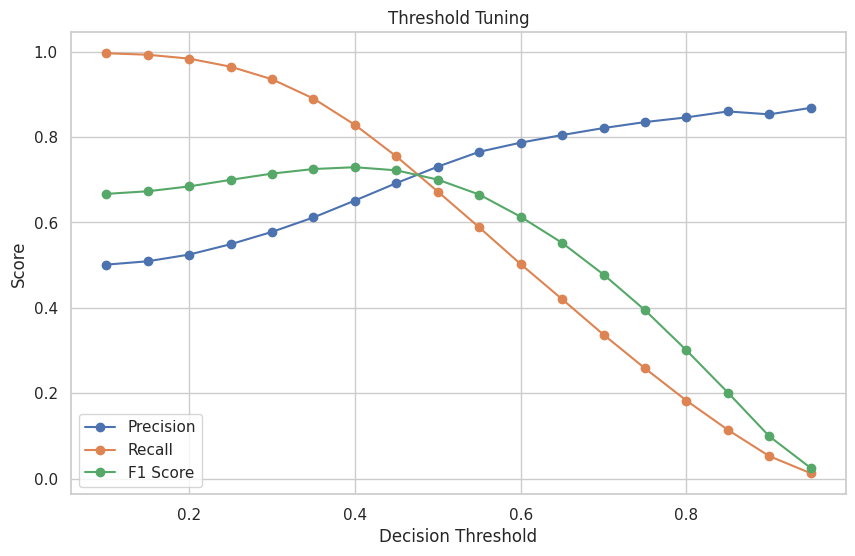

FINAL MODEL PERFORMANCE
Threshold : 0.4
Accuracy : 0.6926666666666667
Precision: 0.6512881965248651
Recall   : 0.8286639984753192
F1 Score : 0.7293466409460706


In [93]:
# =============================================================================
# PRECISION - RECALL vs THRESHOLD
# =============================================================================

plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")

plt.ylabel("Score")

plt.title("Threshold Tuning")

plt.grid(True)

plt.legend()

plt.show()










# Select Best Threshold

# =============================================================================
# FINAL THRESHOLD
# =============================================================================

best_threshold = 0.40

final_prediction = (probabilities >= best_threshold).astype(int)

print("="*70)
print("FINAL MODEL PERFORMANCE")
print("="*70)

print("Threshold :", best_threshold)

print("Accuracy :", accuracy_score(y_test, final_prediction))
print("Precision:", precision_score(y_test, final_prediction))
print("Recall   :", recall_score(y_test, final_prediction))
print("F1 Score :", f1_score(y_test, final_prediction))

# ROC Curve

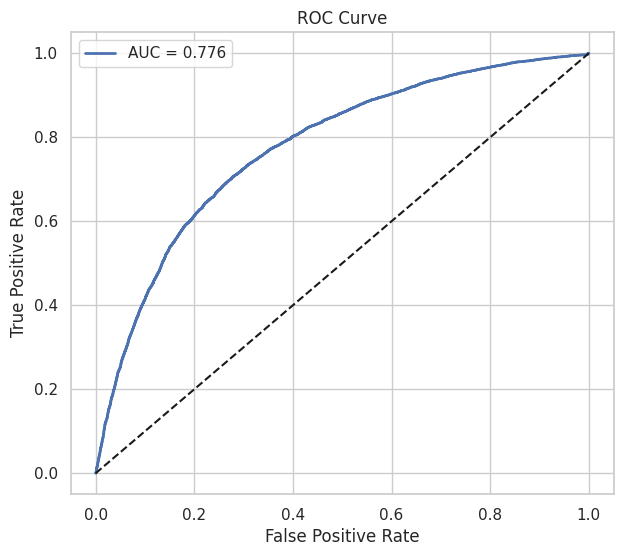

In [94]:
# =============================================================================
# ROC CURVE
# =============================================================================

from sklearn.metrics import roc_curve

# Probability from Best Model
y_prob = best_lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         linewidth=2,
         label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# Resource Consumption Analysis

,Model,Training Time (s),Prediction Time (s),RAM Before (MB),RAM After (MB),Peak Memory (MB),Model Size (MB)
0,Logistic Regression,0.257127,0.001129,949.058594,949.058594,5.694443,0.000915
1,Random Forest,8.302041,0.323425,949.058594,949.058594,6.290100,15.985894
2,XGBoost,0.359118,0.025424,949.058594,949.058594,2.124853,0.223010


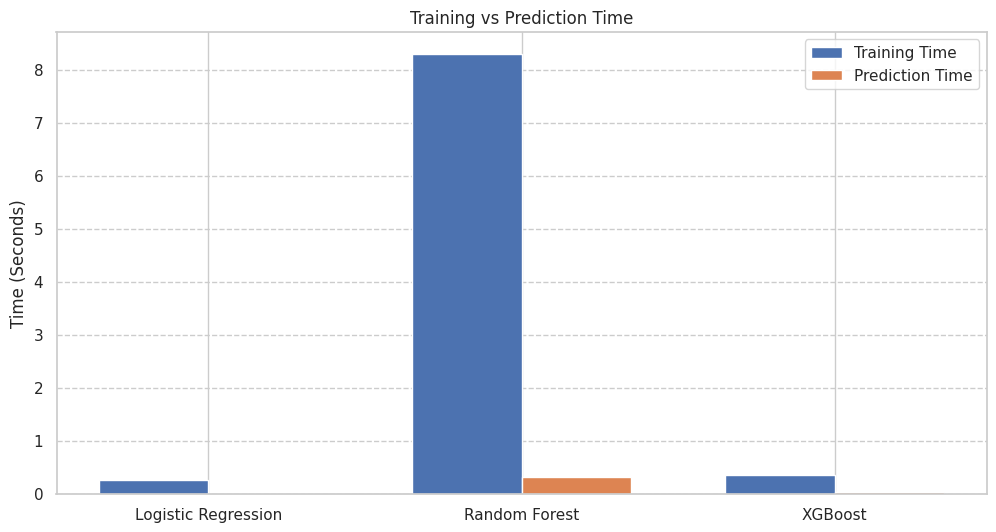

In [95]:
# =============================================================================
# RESOURCE CONSUMPTION ANALYSIS
# =============================================================================

import os
import time
import psutil
import tracemalloc

process = psutil.Process(os.getpid())

results = []

models = {
    "Logistic Regression": (best_lr, X_train_scaled, X_test_scaled),
    "Random Forest": (best_rf, X_train, X_test),
    "XGBoost": (best_xgb, X_train, X_test)
}

for name, (model, train_x, test_x) in models.items():

    tracemalloc.start()

    ram_before = process.memory_info().rss / (1024**2)

    start = time.time()
    model.fit(train_x, y_train)
    training_time = time.time() - start

    ram_after = process.memory_info().rss / (1024**2)

    current, peak = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    start = time.time()
    model.predict(test_x)
    prediction_time = time.time() - start

    joblib.dump(model,"temp.pkl")

    model_size = os.path.getsize("temp.pkl")/(1024*1024)

    results.append([
        name,
        training_time,
        prediction_time,
        ram_before,
        ram_after,
        peak/(1024*1024),
        model_size
    ])

resource_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Training Time (s)",
        "Prediction Time (s)",
        "RAM Before (MB)",
        "RAM After (MB)",
        "Peak Memory (MB)",
        "Model Size (MB)"
    ]
)

display(resource_df)









plt.figure(figsize=(12,6))

x = np.arange(len(resource_df["Model"]))
w = 0.35

plt.bar(x-w/2, resource_df["Training Time (s)"], w, label="Training Time")
plt.bar(x+w/2, resource_df["Prediction Time (s)"], w, label="Prediction Time")

plt.xticks(x, resource_df["Model"])

plt.ylabel("Time (Seconds)")
plt.title("Training vs Prediction Time")

plt.legend()

plt.grid(axis="y", linestyle="--")

plt.show()

# Model Comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7124,0.7307,0.6724,0.7003,0.7764
1,Random Forest,0.7335,0.7600,0.6821,0.7190,0.7992
2,XGBoost,0.7335,0.7517,0.6968,0.7232,0.8000


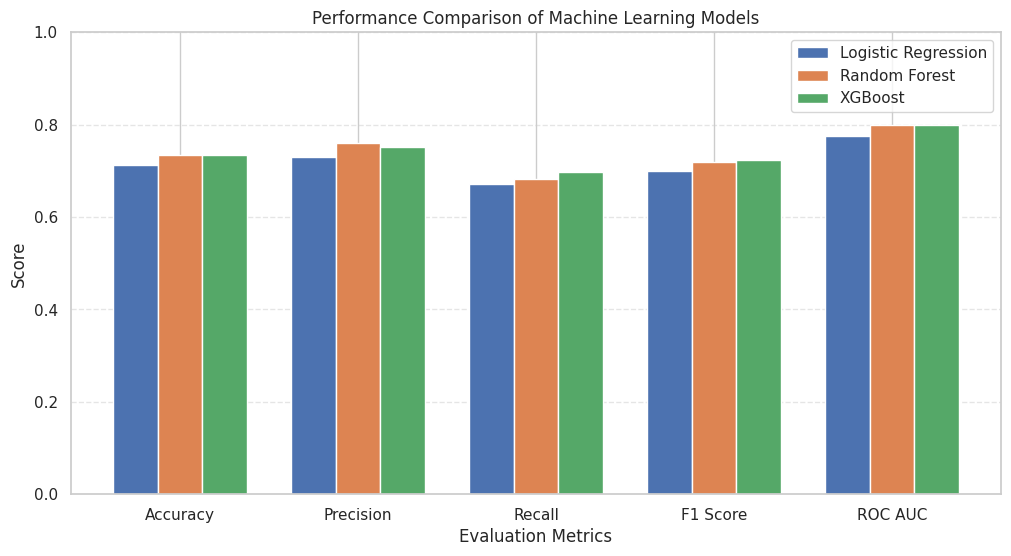

In [96]:
# =============================================================================
# MODEL PERFORMANCE COMPARISON
# =============================================================================

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, best_lr.predict(X_test_scaled)),
        accuracy_score(y_test, best_rf.predict(X_test)),
        accuracy_score(y_test, best_xgb.predict(X_test))
    ],

    "Precision": [
        precision_score(y_test, best_lr.predict(X_test_scaled)),
        precision_score(y_test, best_rf.predict(X_test)),
        precision_score(y_test, best_xgb.predict(X_test))
    ],

    "Recall": [
        recall_score(y_test, best_lr.predict(X_test_scaled)),
        recall_score(y_test, best_rf.predict(X_test)),
        recall_score(y_test, best_xgb.predict(X_test))
    ],

    "F1 Score": [
        f1_score(y_test, best_lr.predict(X_test_scaled)),
        f1_score(y_test, best_rf.predict(X_test)),
        f1_score(y_test, best_xgb.predict(X_test))
    ],

    "ROC AUC": [
        roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])
    ]

})

comparison_df = comparison_df.round(4)

display(comparison_df)





# =============================================================================
# MODEL COMPARISON GRAPH
# =============================================================================

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

plt.figure(figsize=(12,6))

bar_width = 0.25
x = np.arange(len(metrics))

plt.bar(
    x - bar_width,
    comparison_df.loc[0, metrics],
    width=bar_width,
    label="Logistic Regression"
)

plt.bar(
    x,
    comparison_df.loc[1, metrics],
    width=bar_width,
    label="Random Forest"
)

plt.bar(
    x + bar_width,
    comparison_df.loc[2, metrics],
    width=bar_width,
    label="XGBoost"
)

plt.xticks(x, metrics)
plt.ylim(0, 1)

plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("Performance Comparison of Machine Learning Models")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


In [97]:
# =============================================================================
# BEST MODEL
# =============================================================================

best_model_name = comparison_df.sort_values(
    by="ROC AUC",
    ascending=False
).iloc[0]["Model"]

print("="*70)
print("BEST MODEL")
print("="*70)

print(best_model_name)

BEST MODEL
XGBoost


#  Save Best Model

Best model saved successfully as 'best_model.pkl'


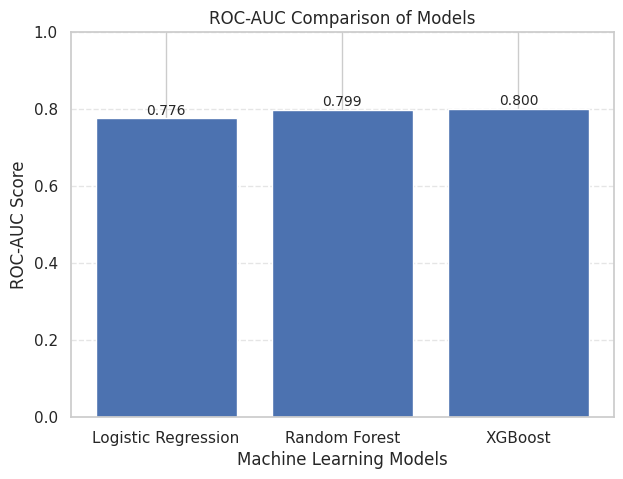

In [98]:
# =============================================================================
# SAVE BEST MODEL
# =============================================================================

import joblib

if best_model_name == "Logistic Regression":
    joblib.dump(best_lr, "best_model.pkl")

elif best_model_name == "Random Forest":
    joblib.dump(best_rf, "best_model.pkl")

else:
    joblib.dump(best_xgb, "best_model.pkl")

print("="*70)
print("Best model saved successfully as 'best_model.pkl'")
print("="*70)


# =============================================================================
# BEST MODEL BASED ON ROC-AUC
# =============================================================================

plt.figure(figsize=(7,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["ROC AUC"]
)

plt.ylabel("ROC-AUC Score")
plt.xlabel("Machine Learning Models")
plt.title("ROC-AUC Comparison of Models")

plt.ylim(0,1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# Sample Prediction

In [99]:
# =============================================================================
# SAMPLE PREDICTION
# =============================================================================

sample_patient = X.iloc[[0]]

if best_model_name == "Logistic Regression":

    probability = best_lr.predict_proba(
        scaler.transform(sample_patient)
    )[0][1]

else:

    if best_model_name == "Random Forest":
        probability = best_rf.predict_proba(sample_patient)[0][1]
    else:
        probability = best_xgb.predict_proba(sample_patient)[0][1]

prediction = "Disease" if probability >= 0.40 else "No Disease"

print("PATIENT PREDICTION")

print(f"Risk Score : {probability*100:.2f}%")
print(f"Prediction : {prediction}")

PATIENT PREDICTION
Risk Score : 17.45%
Prediction : No Disease


#  Project Conclusion

In [100]:
# =============================================================================
# PROJECT CONCLUSION
# =============================================================================


print("PROJECT COMPLETED SUCCESSFULLY")


print(f"Best Model : {best_model_name}")

print("\nModel is now ready for deployment using FastAPI.")
print("The saved model (best_model.pkl) can be integrated with a React frontend")
print("to provide real-time cardiovascular disease risk prediction.")

PROJECT COMPLETED SUCCESSFULLY
Best Model : XGBoost

Model is now ready for deployment using FastAPI.
The saved model (best_model.pkl) can be integrated with a React frontend
to provide real-time cardiovascular disease risk prediction.


#  Paitient1  Testing



In [ ]:
# =============================================================================
# CUSTOM PATIENT PREDICTION
# =============================================================================

patient = pd.DataFrame({
    "age": [34],
    "gender": [4],
    "height": [170],
    "weight": [75],
    "ap_hi": [140],
    "ap_lo": [90],
    "cholesterol": [3],
    "gluc": [1],
    "smoke": [1],
    "alco": [0],
    "active": [1]
})

# Calculate BMI
patient["BMI"] = patient["weight"] / ((patient["height"]/100)**2)

# Keep same feature order as training data
patient = patient[X_train.columns]

display(patient)

# Prediction
prob = best_xgb.predict_proba(patient)[0][1]
pred = best_xgb.predict(patient)[0]

print("="*60)
print("PATIENT PREDICTION")
print("="*60)
print(f"Risk Score : {prob*100:.2f}%")
print("Prediction :", "Disease" if pred == 1 else "No Disease")

# Patient2 testing

In [ ]:
# =============================================================================
# CUSTOM PATIENT PREDICTION
# =============================================================================

patient = pd.DataFrame({
    "age": [14],
    "gender": [2],
    "height": [13],
    "weight": [115],
    "ap_hi": [210],
    "ap_lo": [2120],
    "cholesterol": [3],
    "gluc": [123],
    "smoke": [1],
    "alco": [0],
    "active": [1]
})

# Calculate BMI
patient["BMI"] = patient["weight"] / ((patient["height"]/100)**2)

# Keep same feature order as training data
patient = patient[X_train.columns]

display(patient)

# Prediction
prob = best_xgb.predict_proba(patient)[0][1]
pred = best_xgb.predict(patient)[0]

print("="*60)
print("PATIENT PREDICTION")
print("="*60)
print(f"Risk Score : {prob*100:.2f}%")
print("Prediction :", "Disease" if pred == 1 else "No Disease")

In [103]:
import os

print(os.getcwd())

/kaggle/working


In [104]:


# best_model.pkl successfully save ho chuka hai.
import os

print(os.listdir("/kaggle/working"))

['best_model.pkl', '.virtual_documents', 'temp.pkl']
